In [297]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report 

In [298]:
df=pd.read_csv('loan_approval_dataset.csv')

In [299]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [300]:
df.shape

(1000, 9)

In [301]:
print(df['Loan_Approved'].unique())

['Yes' 'No']


In [302]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [303]:
df.duplicated().sum()

0

In [304]:
df.describe()

,Age,Salary,Credit_Score,Loan_Amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,85197.154000,576.329000,27161.882000
std,13.497852,38105.636581,157.738607,12825.343062
min,18.000000,20060.000000,300.000000,5138.000000
25%,29.000000,52237.250000,442.000000,16181.750000
50%,42.000000,84850.500000,576.000000,26633.500000
75%,52.000000,117480.000000,709.750000,38002.000000
max,64.000000,149972.000000,849.000000,49900.000000


In [305]:
df.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


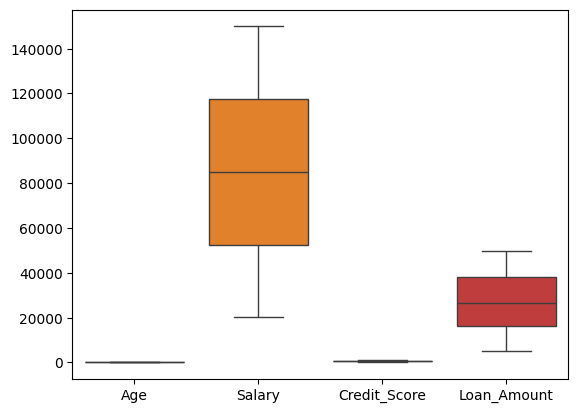

In [306]:
sns.boxplot(df)
plt.show()

In [307]:
df['Loan_Approved'] = df['Loan_Approved'].str.strip()

df['Loan_Approved'] = df['Loan_Approved'].map({
    'Yes': 1,
    'No': 0
})

In [308]:
print(df.corr(numeric_only=True)['Loan_Approved'].sort_values())

Salary          -0.073752
Age             -0.020147
Credit_Score    -0.009898
Loan_Amount      0.037471
Loan_Approved    1.000000
Name: Loan_Approved, dtype: float64


In [332]:
pd.crosstab(
    df['Previous_Default'],
    df['Loan_Approved'],
    normalize='index'
)

Loan_Approved,0,1
Previous_Default,,
No,0.475564,0.524436
Yes,0.510684,0.489316


In [333]:
for col in [
    'Loan_Term',
    'Employment_Status',
    'Residence_Type'
]:
    print("\n", col)
    print(pd.crosstab(
        df[col],
        df['Loan_Approved'],
        normalize='index'
    ))


 Loan_Term
Loan_Approved         0         1
Loan_Term                        
12 months      0.515152  0.484848
24 months      0.484127  0.515873
36 months      0.498008  0.501992
48 months      0.467811  0.532189

 Employment_Status
Loan_Approved             0         1
Employment_Status                    
Employed           0.490323  0.509677
Self-Employed      0.500000  0.500000
Unemployed         0.486111  0.513889

 Residence_Type
Loan_Approved          0         1
Residence_Type                    
Mortgage        0.517341  0.482659
Owned           0.478659  0.521341
Rented          0.478528  0.521472


In [309]:
X=df.drop(columns='Loan_Approved')
y=df['Loan_Approved']

In [310]:
y.value_counts()

Loan_Approved
1    508
0    492
Name: count, dtype: int64

In [311]:
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

In [312]:
for col in num_cols:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR=Q3-Q1

    lower=Q1-1.5 * IQR
    upper=Q3+1.5 * IQR
    
    outlier=df[(df[col]<lower) | (df[col]>upper)]

    print('\n',col)
    print('lower: ',lower)
    print('upper: ',upper)
    print('outlier: ',len(outlier))



 Age
lower:  -5.5
upper:  86.5
outlier:  0

 Salary
lower:  -45626.875
upper:  215344.125
outlier:  0

 Credit_Score
lower:  40.375
upper:  1111.375
outlier:  0

 Loan_Amount
lower:  -16548.625
upper:  70732.375
outlier:  0


In [313]:
X[obj_cols]=X[obj_cols].astype('category')
X[obj_cols]

,Loan_Term,Employment_Status,Residence_Type,Previous_Default
0,36 months,Employed,Owned,Yes
1,24 months,Self-Employed,Rented,No
2,12 months,Unemployed,Rented,Yes
3,24 months,Unemployed,Owned,No
4,12 months,Employed,Owned,No
...,...,...,...,...
995,24 months,Self-Employed,Owned,No
996,48 months,Self-Employed,Owned,No
997,36 months,Self-Employed,Rented,Yes
998,12 months,Self-Employed,Mortgage,No


In [314]:
for col in obj_cols:
    print('\n col')
    print(df[col].unique())


 col
['36 months' '24 months' '12 months' '48 months']

 col
['Employed' 'Self-Employed' 'Unemployed']

 col
['Owned' 'Rented' 'Mortgage']

 col
['Yes' 'No']


In [315]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)

In [316]:
print(df['Loan_Approved'].unique())
print(df['Loan_Approved'].isnull().sum())

print(ytrain.value_counts())
print(ytest.value_counts())

[1 0]
0
Loan_Approved
1    406
0    394
Name: count, dtype: int64
Loan_Approved
1    102
0     98
Name: count, dtype: int64


In [317]:
preprocessor=ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),num_cols),
        ('encoding',OneHotEncoder(handle_unknown='ignore'),obj_cols)
    ],
    remainder='passthrough'
)

In [318]:
main_pipe_LR=Pipeline(
    steps=[
        ('preprocess',preprocessor),
        ('model',LogisticRegression(max_iter=1000))
    ]
)

In [319]:
main_pipe_LR.fit(Xtrain,ytrain)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoding', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [320]:
ypred_test_LR=main_pipe_LR.predict(Xtest)
ypred_train_LR=main_pipe_LR.predict(Xtrain)

In [321]:
print(classification_report(ytrain, ypred_train_LR))
print(classification_report(ytest,ypred_test_LR))

              precision    recall  f1-score   support

           0       0.55      0.51      0.53       394
           1       0.55      0.59      0.57       406

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800

              precision    recall  f1-score   support

           0       0.51      0.52      0.52        98
           1       0.53      0.52      0.52       102

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200



In [322]:
main_pipe=Pipeline(
    steps=[
        ('model',XGBClassifier(enable_categorical=True,max_depth=5,n_estimators=100,learning_rate=0.01))
    ]
)

In [323]:
Xtrain.shape

(800, 8)

In [324]:
model = XGBClassifier()

params = model.get_params()
print(params)

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [325]:
main_pipe.fit(Xtrain,ytrain)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [326]:
ypred_test=main_pipe.predict(Xtest)
ypred_train=main_pipe.predict(Xtrain)

In [327]:
print(accuracy_score(ytrain, ypred_train))
print(accuracy_score(ytest,ypred_test))

0.74875
0.48


In [328]:
print(classification_report(ytrain, ypred_train))
print(classification_report(ytest,ypred_test))

              precision    recall  f1-score   support

           0       0.78      0.69      0.73       394
           1       0.73      0.81      0.77       406

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800

              precision    recall  f1-score   support

           0       0.47      0.44      0.45        98
           1       0.49      0.52      0.50       102

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.48      0.48       200



In [329]:
print(main_pipe.score(Xtrain,ytrain))
print(main_pipe.score(Xtest,ytest))

0.74875
0.48


In [330]:
print(pd.crosstab(ytrain, ypred_train))
print(pd.crosstab(ytest, ypred_test))

col_0            0    1
Loan_Approved          
0              271  123
1               78  328
col_0           0   1
Loan_Approved        
0              43  55
1              49  53


In [331]:
print(Xtrain.dtypes)
print(Xtest.dtypes)

Age                     int64
Salary                  int64
Credit_Score            int64
Loan_Amount             int64
Loan_Term            category
Employment_Status    category
Residence_Type       category
Previous_Default     category
dtype: object
Age                     int64
Salary                  int64
Credit_Score            int64
Loan_Amount             int64
Loan_Term            category
Employment_Status    category
Residence_Type       category
Previous_Default     category
dtype: object
